In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
#Tarea 1. Modelo de crecimiento logístico
#aplicado a usuarios de una aplicación.

#Una aplicación nueva tiene inicialmente P0=250 usuarios.
#Se estima que la cantiad máxima de usuarios que podría alcanzar en
#ese mercado es K=5000. Supongamos que la tasa de crecimiento es
#r=0.12 por semana.

In [ ]:
#Usaremos el modelo logístico discreto
# P_t+1 = P_t + rP_t(1-P_t/K)

In [ ]:
# Parámetros del modelo
P0 = 250  #usuarios
K = 5000
r = 0.12  #tasa de crecimiento
n = 80    #número de semanas

semanas = np.arange(0, n + 1)

#Simulación de modelo logístico
P_log = P0
usuarios_log = []

for t in semanas:
  usuarios_log.append(P_log)
  P_log = P_log + r * P_log * (1- P_log / K)

usuarios_log


[250,
 278.5,
 310.058506,
 344.9582560685692,
 383.49733803448066,
 425.98733359990956,
 472.75064863059725,
 524.1168902475333,
 580.4181527258114,
 641.9830854845814,
 709.1296409735718,
 782.1564415454251,
 861.332765753652,
 946.8872384434302,
 1038.9954164407932,
 1137.7665910044489,
 1243.2302743504415,
 1355.3229909110191,
 1473.8761399877337,
 1598.6058157616583,
 1729.1055403525693,
 1864.8428619226067,
 2005.1606717613909,
 2149.2838887028715,
 2296.3318457255104,
 2445.3363085159367,
 2595.2645936559366,
 2745.0467854286303,
 2893.6056351794564,
 3039.8874256743757,
 3182.8919432967446,
 3321.699749547474,
 3455.4951780657207,
 3583.5838732183565,
 3705.404176971183,
 3820.5321954545534,
 3928.6808687529847,
 4029.6937721592058,
 4123.534659281222,
 4210.273904323924,
 4290.073020456451,
 4363.168346410865,
 4429.854835521247,
 4490.470683052813,
 4545.383318090588,
 4594.977088060429,
 4639.642792072474,
 4679.769081408449,
 4715.735643450107,
 4747.908016850381,
 4776.633

In [ ]:
df = pd.DataFrame({
    "Semana": semanas,
    "Usuarios": usuarios_log
})

df

,Semana,Usuarios
0,0,250.000000
1,1,278.500000
2,2,310.058506
3,3,344.958256
4,4,383.497338
...,...,...
76,76,4991.541731
77,77,4992.555006
78,78,4993.447075
79,79,4994.232396


/tmp/ipykernel_836/3367775637.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


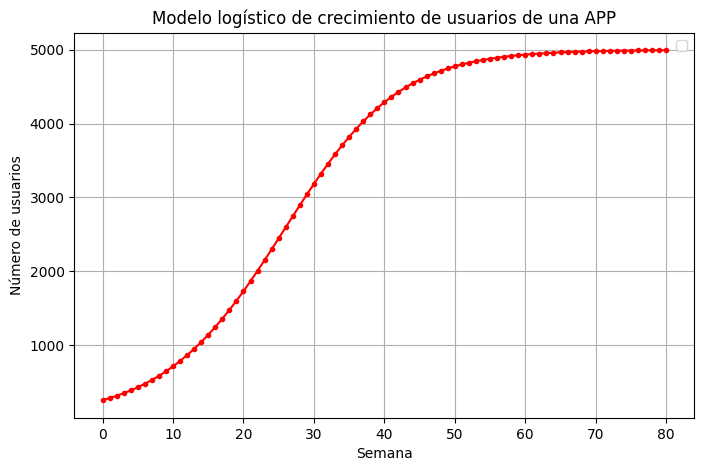

In [ ]:
# Gráfica de la evolución de usuarios con el tiempo

plt.figure(figsize=(8,5))

plt.plot(df["Semana"], df["Usuarios"], marker="o", markersize=3, color='red')
plt.xlabel("Semana")
plt.ylabel("Número de usuarios")
plt.title("Modelo logístico de crecimiento de usuarios de una APP")
plt.legend()
plt.grid()

plt.show()

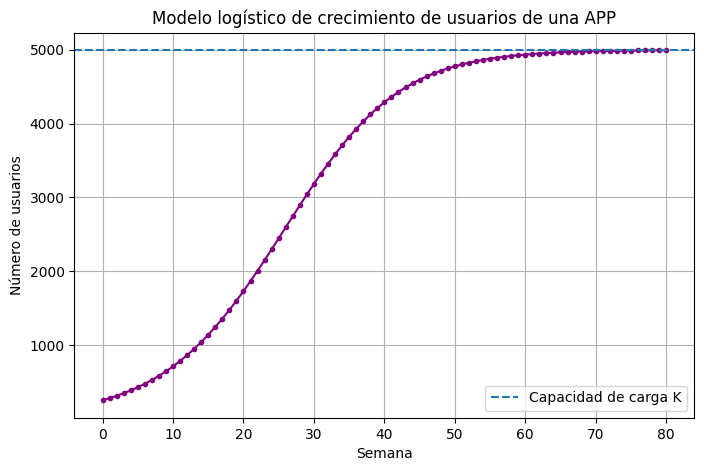

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(df["Semana"], df["Usuarios"], marker="o", markersize=3, color='purple')

plt.axhline(y=K, linestyle="--", label="Capacidad de carga K")

plt.xlabel("Semana")
plt.ylabel("Número de usuarios")
plt.title("Modelo logístico de crecimiento de usuarios de una APP")
plt.legend()
plt.grid()

plt.show()

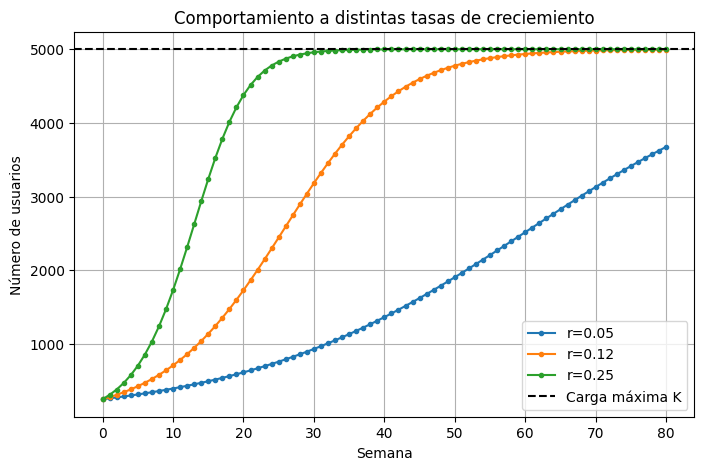

In [ ]:
# Análisis de la sensibilidad del modelo

P0 = 250
K = 5000
n = 80

tasas = [0.05, 0.12, 0.25]
semanas = np.arange(0, n+1)

plt.figure(figsize = (8, 5))

for r in tasas:
  P = P0
  usuarios = []

  for t in semanas:
    usuarios.append(P)
    P = P + r * P * (1 - P / K)

  plt.plot(semanas, usuarios, marker="o", markersize=3, label=f"r={r}")

plt.axhline(y=K, linestyle="--", label="Carga máxima K", color='black')

plt.xlabel("Semana")
plt.ylabel("Número de usuarios")
plt.title("Comportamiento a distintas tasas de creciemiento")
plt.legend()
plt.grid()
plt.show()


¿Qué ocurre cuando aumenta $r$?
La cantidad de usuarios de la aplicación crece de manera más rápida, llegando en menos semanas a la cantidad máxima de usuarios, es decir, $r$ controla que tan rápida es la convergencia a $K$.

¿La población de usuarios crece indefinidamente? No, el número de usuarios no crece indefinidamente porque el modelo logístico discreto
 $$P_{t+1}= P_{t}+rP_{t}\left(1-\frac{P_{t}}{K}\right)$$

 precisamente establece un tope en el crecimiento, el tope está dado por
 $$\left( 1- \frac{P_t}{K}\right)$$
 y se alcanza cuando $P_{t} \rightarrow K$, pues así $P_{t}/K →1$, en consecuencia,
 $$\left( 1- \frac{P_t}{K}\right) \rightarrow 0$$

 y así la población de usuarios deja de crecer.

¿Qué representa la capacidad de carga $K$ en este problema? En este caso, la capacidad de carga $K$ representa el número máximo de usuarios que se puede alcanzar, de manera sostenible, es decir, por ejemplo para que la aplicación no tenga fallos o no se sobrecargue.